In [1]:
import requests
import zipfile
from pathlib import Path

In [28]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data.sampler import SubsetRandomSampler
import torch.optim
import torch.multiprocessing
torch.multiprocessing.set_sharing_strategy('file_system')

import torchvision as tv
from torchvision import datasets
import torchvision.transforms as T
import torchvision.models

import random
import multiprocessing
import numpy as np
import pandas as pd
import seaborn as sns
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image

from livelossplot import PlotLosses
from livelossplot.outputs import MatplotlibPlot

In [2]:
curr_path = '/Users/josephhorzempa/Documents/Math474/projects/proj3/ml2_proj3'

In [3]:
import os
print(os.getcwd())
print(os.path.exists(curr_path + '/data/images/veggies/train/Bean/0026.jpg'))


/Users/josephhorzempa/Documents/Math474/projects/proj3/ml2_proj3
True


In [4]:
%pip install opencv-python


Note: you may need to restart the kernel to use updated packages.


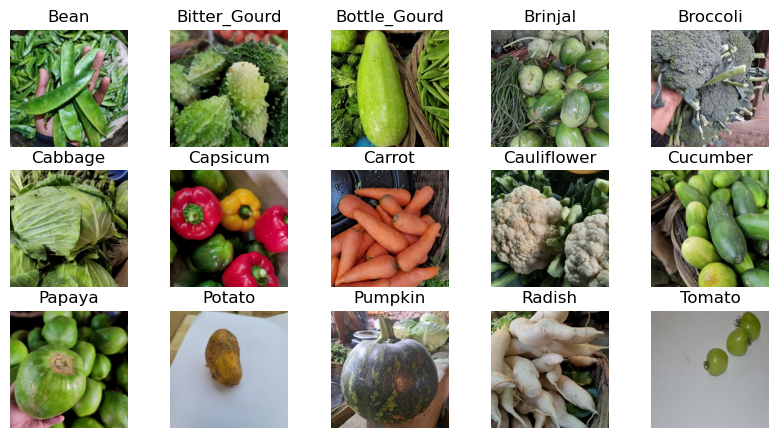

In [19]:
import cv2 
from matplotlib import pyplot as plt  

fig = plt.figure(figsize=(10, 7))

# Read the images using OpenCV (OpenCV loads images in BGR format)
image1 = cv2.imread(curr_path + '/data/images/veggies/test/Bean/0001.jpg')
image2 = cv2.imread(curr_path + '/data/images/veggies/test/Bitter_Gourd/1201.jpg')
image3 = cv2.imread(curr_path + '/data/images/veggies/test/Bottle_Gourd/1001.jpg')
image4 = cv2.imread(curr_path + '/data/images/veggies/test/Brinjal/0871.jpg')
image5 = cv2.imread(curr_path + '/data/images/veggies/test/Broccoli/1001.jpg')
image6 = cv2.imread(curr_path + '/data/images/veggies/test/Cabbage/0929.jpg')
image7 = cv2.imread(curr_path + '/data/images/veggies/test/Capsicum/1001.jpg')
image8 = cv2.imread(curr_path + '/data/images/veggies/test/Carrot/1001.jpg')
image9 = cv2.imread(curr_path + '/data/images/veggies/test/Cauliflower/1048.jpg')
image10 = cv2.imread(curr_path + '/data/images/veggies/test/Cucumber/1001.jpg')
image11 = cv2.imread(curr_path + '/data/images/veggies/test/Papaya/1198.jpg')
image12 = cv2.imread(curr_path + '/data/images/veggies/test/Potato/1001.jpg')
image13 = cv2.imread(curr_path + '/data/images/veggies/test/Pumpkin/1001.jpg')
image14 = cv2.imread(curr_path + '/data/images/veggies/test/Radish/1001.jpg')
image15 = cv2.imread(curr_path + '/data/images/veggies/test/Tomato/1001.jpg')

# Convert the images from BGR to RGB format so Matplotlib can display them correctly
image1 = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)
image2 = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
image3 = cv2.cvtColor(image3, cv2.COLOR_BGR2RGB)
image4 = cv2.cvtColor(image4, cv2.COLOR_BGR2RGB)
image5 = cv2.cvtColor(image5, cv2.COLOR_BGR2RGB)
image6 = cv2.cvtColor(image6, cv2.COLOR_BGR2RGB)
image7 = cv2.cvtColor(image7, cv2.COLOR_BGR2RGB)
image8 = cv2.cvtColor(image8, cv2.COLOR_BGR2RGB)
image9 = cv2.cvtColor(image9, cv2.COLOR_BGR2RGB)
image10 = cv2.cvtColor(image10, cv2.COLOR_BGR2RGB)
image11 = cv2.cvtColor(image11, cv2.COLOR_BGR2RGB)
image12 = cv2.cvtColor(image12, cv2.COLOR_BGR2RGB)
image13 = cv2.cvtColor(image13, cv2.COLOR_BGR2RGB)
image14 = cv2.cvtColor(image14, cv2.COLOR_BGR2RGB)
image15 = cv2.cvtColor(image15, cv2.COLOR_BGR2RGB)


# Add the first image to the figure (top-left position)
plt.subplot(4, 5, 1)  # 2 rows, 2 columns, first position
plt.imshow(image1)  
plt.axis('off')  # Hide the axis labels
plt.title("Bean") 

plt.subplot(4, 5, 2)  # 2 rows, 2 columns, first position
plt.imshow(image2)  
plt.axis('off')  # Hide the axis labels
plt.title("Bitter_Gourd") 

plt.subplot(4, 5, 3)  # 2 rows, 2 columns, first position
plt.imshow(image3)  
plt.axis('off')  # Hide the axis labels
plt.title("Bottle_Gourd") 

plt.subplot(4, 5, 4)  # 2 rows, 2 columns, first position
plt.imshow(image4)  
plt.axis('off')  # Hide the axis labels
plt.title("Brinjal") 

plt.subplot(4, 5, 5)  # 2 rows, 2 columns, first position
plt.imshow(image5)  
plt.axis('off')  # Hide the axis labels
plt.title("Broccoli") 

plt.subplot(4, 5, 6)  # 2 rows, 2 columns, first position
plt.imshow(image6)  
plt.axis('off')  # Hide the axis labels
plt.title("Cabbage") 

plt.subplot(4, 5, 7)  # 2 rows, 2 columns, first position
plt.imshow(image7)  
plt.axis('off')  # Hide the axis labels
plt.title("Capsicum") 

plt.subplot(4, 5, 8)  # 2 rows, 2 columns, first position
plt.imshow(image8)  
plt.axis('off')  # Hide the axis labels
plt.title("Carrot") 

plt.subplot(4, 5, 9)  # 2 rows, 2 columns, first position
plt.imshow(image9)  
plt.axis('off')  # Hide the axis labels
plt.title("Cauliflower") 

plt.subplot(4, 5, 10)  # 2 rows, 2 columns, first position
plt.imshow(image10)  
plt.axis('off')  # Hide the axis labels
plt.title("Cucumber") 

plt.subplot(4, 5, 11)  # 2 rows, 2 columns, first position
plt.imshow(image11)  
plt.axis('off')  # Hide the axis labels
plt.title("Papaya") 

plt.subplot(4, 5, 12)  # 2 rows, 2 columns, first position
plt.imshow(image12)  
plt.axis('off')  # Hide the axis labels
plt.title("Potato") 

plt.subplot(4, 5, 13)  # 2 rows, 2 columns, first position
plt.imshow(image13)  
plt.axis('off')  # Hide the axis labels
plt.title("Pumpkin") 

plt.subplot(4, 5, 14)  # 2 rows, 2 columns, first position
plt.imshow(image14)  
plt.axis('off')  # Hide the axis labels
plt.title("Radish") 

plt.subplot(4, 5, 15)  # 2 rows, 2 columns, first position
plt.imshow(image15)  
plt.axis('off')  # Hide the axis labels
plt.title("Tomato") 

plt.show()

In [23]:
mean = (0.4688234031200409, 0.4635027050971985, 0.3433191776275635)
std = (0.19028286635875702, 0.19179819524288177, 0.1834646761417389)

data_transform = T.Compose([
    T.Resize(256), # All images in CIFAR-10 are 32x32. We enlarge them a bit so we can then take a random crop
    T.RandomCrop(224), # take a random part of the image
    T.RandomHorizontalFlip(0.5),
    T.RandAugment(num_ops=2, magnitude=2, interpolation=T.InterpolationMode.BILINEAR,),
    T.ToTensor(),
    T.Normalize(mean, std),])

In [26]:
image_path_list = [curr_path + '/data/images/veggies/test/Bean/0001.jpg',
              curr_path + '/data/images/veggies/test/Bitter_Gourd/1201.jpg',
              curr_path + '/data/images/veggies/test/Bottle_Gourd/1001.jpg']

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4638236..2.429163].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4638236..3.5152059].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.4638236..2.5533283].


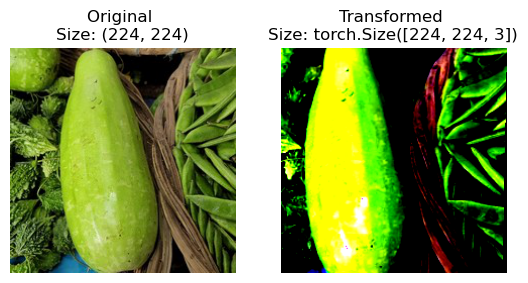

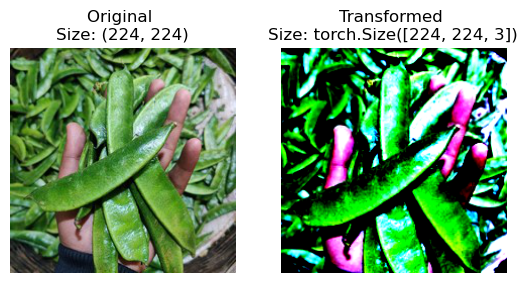

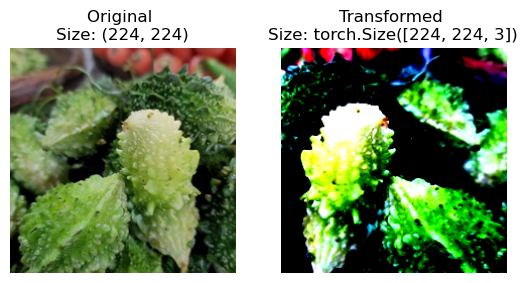

In [30]:
def plot_transformed_images(image_paths, transform, n=3, seed=42):
    """Plots a series of random images from image_paths.

    Will open n image paths from image_paths, transform them
    with transform and plot them side by side.

    Args:
        image_paths (list): List of target image paths. 
        transform (PyTorch Transforms): Transforms to apply to images.
        n (int, optional): Number of images to plot. Defaults to 3.
        seed (int, optional): Random seed for the random generator. Defaults to 42.
    """
    random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f) 
            ax[0].set_title(f"Original \nSize: {f.size}")
            ax[0].axis("off")

            # Transform and plot image
            # Note: permute() will change shape of image to suit matplotlib 
            # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
            transformed_image = transform(f).permute(1, 2, 0) 
            ax[1].imshow(transformed_image) 
            ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
            ax[1].axis("off")


plot_transformed_images(image_path_list, 
                        transform=data_transform, 
                        n=3)

In [38]:
train_data = datasets.CIFAR100("data", train=True, download=True)
all_labels = train_data.targets
train_data = (train_data.data / 255.)

In [32]:
classes = ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 
           'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 
           'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 
           'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 
           'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 
           'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 
           'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 
           'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 
           'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 
           'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 
           'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 
           'tiger', 'tractor', 'train', 'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 
           'woman', 'worm']

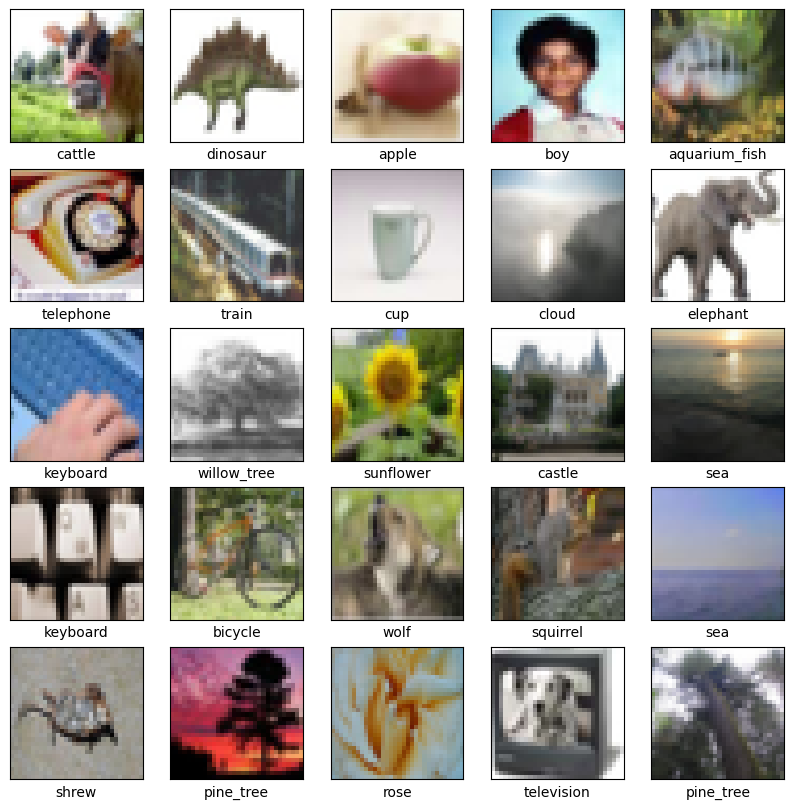

In [42]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_data[i], cmap=plt.cm.binary)
    plt.xlabel(classes[all_labels[i]])
plt.show()

In [48]:
mean = (0.5071, 0.4867, 0.4408)
std = (0.2470, 0.2435, 0.2616)

data_transform = T.Compose([
    T.Resize(256), # All images in CIFAR-10 are 32x32. We enlarge them a bit so we can then take a random crop
    T.RandomCrop(224), # take a random part of the image
    T.RandomHorizontalFlip(0.5),
    T.RandAugment(num_ops=2, magnitude=2, interpolation=T.InterpolationMode.BILINEAR,),
    T.ToTensor(),
    T.Normalize(mean, std),])

In [52]:
train_data = datasets.CIFAR100("data", train=True, download=True)

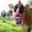

In [53]:
train_data[0][0]

In [57]:
image_path_list = [train_data[0][0], train_data[1][0], train_data[2][0]]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8860329..1.8977635].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1290978..2.1376147].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0530365..1.867782].


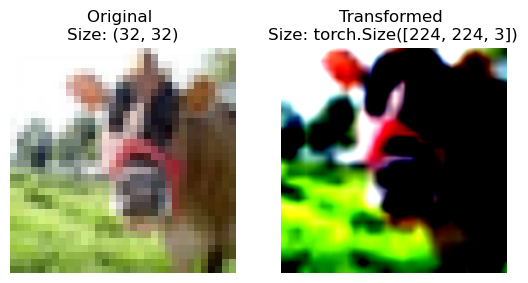

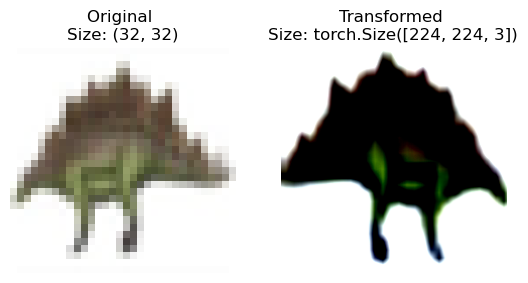

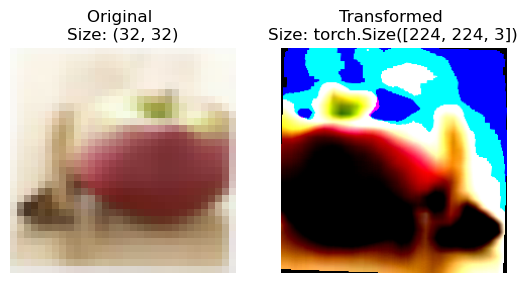

In [58]:
def plot_transformed_images(image_list, transform, n=3, seed=42):
    random.seed(seed)
    for image in image_list:
        fig, ax = plt.subplots(1, 2)
        ax[0].imshow(image) 
        ax[0].set_title(f"Original \nSize: {image.size}")
        ax[0].axis("off")

        # Transform and plot image
        # Note: permute() will change shape of image to suit matplotlib 
        # (PyTorch default is [C, H, W] but Matplotlib is [H, W, C])
        transformed_image = transform(image).permute(1, 2, 0) 
        ax[1].imshow(transformed_image) 
        ax[1].set_title(f"Transformed \nSize: {transformed_image.shape}")
        ax[1].axis("off")


plot_transformed_images(image_path_list, 
                        transform=data_transform, 
                        n=3)